<a href="https://colab.research.google.com/github/jaison-leonardo/projects-ML-DL-iue/blob/main/Exoplanetas_con_Spark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyspark

In [ ]:
from google.colab import drive
from pyspark.sql import SparkSession, functions as F
import matplotlib.pyplot as plt

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
spark = SparkSession.builder \
    .appName("AstronomiaBigData") \
    .getOrCreate()

In [ ]:
path = "/content/drive/MyDrive/Colab Notebooks/Big data files/exoplanets.csv"
df = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv(path)

# Ver columnas
print(df.columns)
df.show(5)


['kepid', 'kepoi_name', 'kepler_name', 'koi_disposition', 'koi_pdisposition', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_period_err1', 'koi_period_err2', 'koi_time0bk', 'koi_time0bk_err1', 'koi_time0bk_err2', 'koi_impact', 'koi_impact_err1', 'koi_impact_err2', 'koi_duration', 'koi_duration_err1', 'koi_duration_err2', 'koi_depth', 'koi_depth_err1', 'koi_depth_err2', 'koi_prad', 'koi_prad_err1', 'koi_prad_err2', 'koi_teq', 'koi_teq_err1', 'koi_teq_err2', 'koi_insol', 'koi_insol_err1', 'koi_insol_err2', 'koi_model_snr', 'koi_tce_plnt_num', 'koi_tce_delivname', 'koi_steff', 'koi_steff_err1', 'koi_steff_err2', 'koi_slogg', 'koi_slogg_err1', 'koi_slogg_err2', 'koi_srad', 'koi_srad_err1', 'koi_srad_err2', 'ra', 'dec', 'koi_kepmag']
+--------+----------+------------+---------------+----------------+---------+-------------+-------------+-------------+-------------+-----------+---------------+---------------+-----------+----------------+--

In [11]:
# limpieza de datos y eliminación de outliers, planetas con un límite menor a 20 radios
df_clean = df.filter(
    (F.col("koi_prad").isNotNull()) &
    (F.col("koi_prad") < 20)
)
analisis = (
    df.select("koi_disposition", "koi_prad", "koi_steff")
      .groupBy("koi_disposition")
      .agg(
          F.count("*").alias("cantidad"),
          F.avg("koi_prad").alias("radio_promedio_planeta"),
          F.avg("koi_steff").alias("temp_promedio_estrella")
      )
      .orderBy(F.desc("cantidad"))
)

analisis.show(20, truncate=False)

+---------------+--------+----------------------+----------------------+
|koi_disposition|cantidad|radio_promedio_planeta|temp_promedio_estrella|
+---------------+--------+----------------------+----------------------+
|FALSE POSITIVE |4840    |164.80583678813014    |5857.039275583679     |
|CANDIDATE      |2367    |81.61612290008847     |5640.136604774536     |
|CONFIRMED      |2357    |2.880488115449917     |5478.642190152801     |
+---------------+--------+----------------------+----------------------+



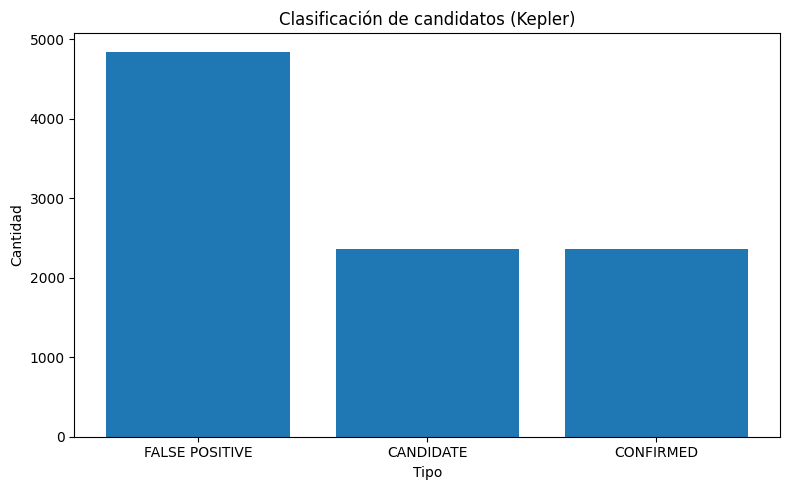

In [12]:
pdf = analisis.toPandas()
plt.figure(figsize=(8,5))
plt.bar(pdf["koi_disposition"], pdf["cantidad"])
plt.title("Clasificación de candidatos (Kepler)")
plt.xlabel("Tipo")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

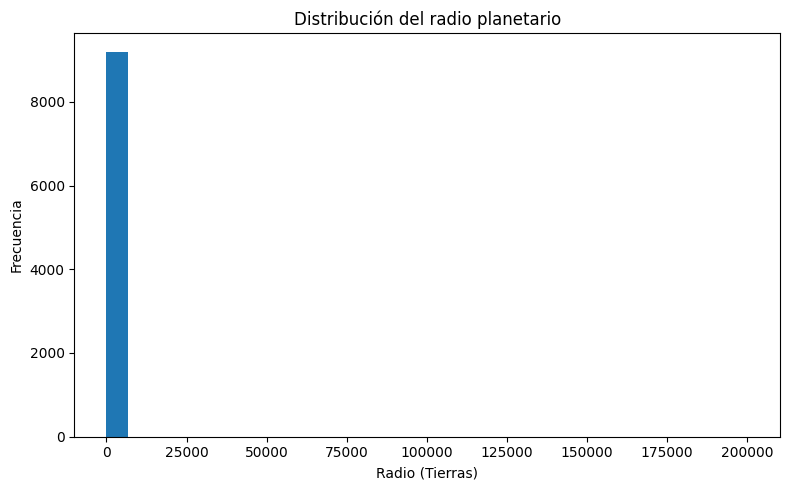

In [13]:
radios = df.select("koi_prad") \
           .where(F.col("koi_prad").isNotNull()) \
           .toPandas()

plt.figure(figsize=(8,5))
plt.hist(radios["koi_prad"], bins=30)
plt.title("Distribución del radio planetario")
plt.xlabel("Radio (Tierras)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

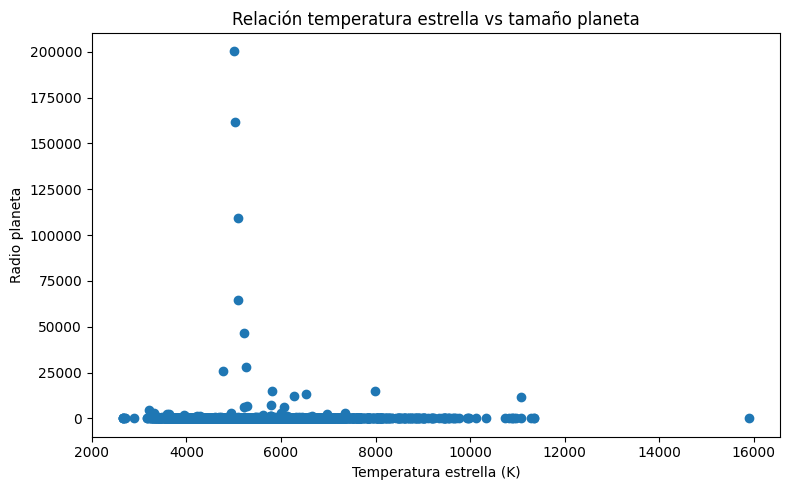

In [14]:
scatter = df.select("koi_steff", "koi_prad") \
            .where(
                (F.col("koi_steff").isNotNull()) &
                (F.col("koi_prad").isNotNull())
            ) \
            .toPandas()

plt.figure(figsize=(8,5))
plt.scatter(scatter["koi_steff"], scatter["koi_prad"])
plt.title("Relación temperatura estrella vs tamaño planeta")
plt.xlabel("Temperatura estrella (K)")
plt.ylabel("Radio planeta")
plt.tight_layout()
plt.show()